In [6]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

In [7]:
def load_images(folder, label, size=(64, 64), max_images=100):
    data = []
    labels = []
    folder_path = Path(folder)
    
    for i, file_path in enumerate(folder_path.iterdir()):
        if i >= max_images:  # Stop after max_images
            break
        img = Image.open(file_path)
        img = img.convert("RGB")
        img = img.resize(size)
        img_array = np.array(img)
        data.append(img_array)
        labels.append(label)
    
    return data, labels
print("DONE")

DONE


In [9]:
dog_imgs, dog_labels = load_images("Dog", 1)
notdog_imgs, notdog_labels = load_images("Cat", 0)
print("Done loading")

Done loading


In [12]:
X=np.array(dog_imgs+notdog_imgs)
Y=np.array(dog_labels+notdog_labels)
print("DONE")

DONE


In [13]:
indices=np.random.permutation(X.shape[0])

In [14]:
X = X[indices]
Y = Y[indices]

In [15]:
m=X.shape[0]

In [16]:
split = int(m * 0.8)

In [17]:
train_x_orig = X[:split]
test_x_orig  = X[split:]

In [18]:
train_y = Y[:split].reshape(1, -1)
test_y  = Y[split:].reshape(1, -1)

In [20]:
train_x_orig.shape

(160, 64, 64, 3)

In [21]:
test_x_orig.shape

(40, 64, 64, 3)

In [22]:
train_y.shape

(1, 160)

In [23]:
test_y.shape

(1, 40)

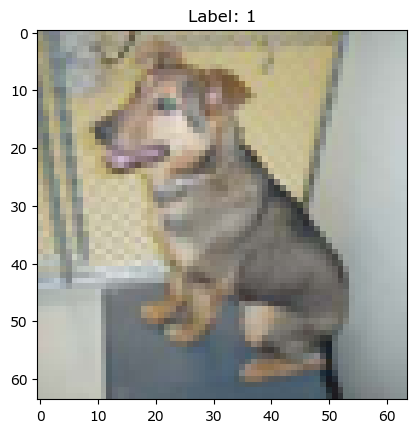

In [37]:
plt.imshow(train_x_orig[0])
plt.title("Label: " + str(train_y[0][0]))
plt.show()

In [38]:
train_x_flatten = train_x_orig.reshape(64*64*3, -1)
test_x_flatten=test_x_orig.reshape(64*64*3, -1)

In [39]:
train_x_norm = train_x_flatten / 255
test_x_norm = test_x_flatten / 255

In [40]:
print(train_x_flatten.shape)  # should be (12288, 160)
print(test_x_flatten.shape)   # should be (12288, 40)

(12288, 160)
(12288, 40)


In [45]:
def parameters(dims=train_x_flatten.shape[0]):
    w=np.zeros((dims,1))
    b=0.0        # should be 0.0
    return w , b

In [46]:
w, b = parameters()

In [47]:
print(w.shape)  # should be (12288, 1)
print(b)        # should be 0.0

(12288, 1)
0.0


In [48]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [49]:
print(sigmoid(0))    # should be 0.5
print(sigmoid(100))  # should be ≈ 1.0
print(sigmoid(-100)) # should be ≈ 0.0

0.5
1.0
3.7200759760208356e-44


In [50]:
def forward_propagation(w,b,X):
    Z=np.dot(w.T,X)+b
    A=sigmoid(Z)
    return Z,A
    

In [51]:
def cost(Y,A):
    m=Y.shape[1] 
    return -1/m *np.sum(Y*np.log(A)+(1-Y)*np.log(1-A))
    

In [52]:
def backward_propagation(X,A,Y):
    m=Y.shape[1]
    dw=1/m * np.dot(X,(A-Y).T)
    db=1/m * np.sum(A-Y)
    return dw,db

In [54]:
def gradient(w, b, X, Y, num_iterations, learning_rate):
    costs=[]
    for i in range(num_iterations):
        Z, A = forward_propagation(w, b, X)  # returns BOTH Z and A!
        c=cost(Y,A)
        if i%100==0:
            costs.append(c)
            print(f"Cost after iteration {i} : {c}")
        dw,db=backward_propagation(X,A,Y)
        w=w-learning_rate*dw
        b=b-learning_rate*db
    return w,b,costs

In [55]:
def predict(w,b,X):
    Z,A=forward_propagation(w,b,X)
    Y_prediction=(A>0.5).astype(int)
    
    return Y_prediction

In [59]:
w, b = parameters(train_x_norm.shape[0])
w, b, costs = gradient(w, b, train_x_norm, train_y, 2000, 0.001)
Y_prediction_train = predict(w, b, train_x_norm)
Y_prediction_test = predict(w, b, test_x_norm)

Cost after iteration 0 : 0.6931471805599454
Cost after iteration 100 : 0.66325430870006
Cost after iteration 200 : 0.6484437110065412
Cost after iteration 300 : 0.6369479841417282
Cost after iteration 400 : 0.6271210367310699
Cost after iteration 500 : 0.6184257569678295
Cost after iteration 600 : 0.6105824668217894
Cost after iteration 700 : 0.6034119896466517
Cost after iteration 800 : 0.5967885588642341
Cost after iteration 900 : 0.5906194355216515
Cost after iteration 1000 : 0.5848340194336309
Cost after iteration 1100 : 0.5793772941762942
Cost after iteration 1200 : 0.5742055786312625
Cost after iteration 1300 : 0.5692836372983464
Cost after iteration 1400 : 0.564582648748035
Cost after iteration 1500 : 0.5600787425020631
Cost after iteration 1600 : 0.5557519251065859
Cost after iteration 1700 : 0.5515852791578991
Cost after iteration 1800 : 0.5475643573617708
Cost after iteration 1900 : 0.543676718131039


In [60]:
acc_1 = 100 - np.mean(np.abs(Y_prediction_train - train_y)) * 100
acc_2 = 100 - np.mean(np.abs(Y_prediction_test - test_y)) * 100

print("Train accuracy:", acc_1, "%")
print("Test accuracy:", acc_2, "%")

Train accuracy: 77.5 %
Test accuracy: 52.5 %


In [61]:
w, b = parameters(train_x_norm.shape[0])
w, b, costs = gradient(w, b, train_x_norm, train_y, 5000, 0.001)
Y_prediction_train = predict(w, b, train_x_norm)
Y_prediction_test = predict(w, b, test_x_norm)

acc_1 = 100 - np.mean(np.abs(Y_prediction_train - train_y)) * 100
acc_2 = 100 - np.mean(np.abs(Y_prediction_test - test_y)) * 100

print("Train accuracy:", acc_1, "%")
print("Test accuracy:", acc_2, "%")

Cost after iteration 0 : 0.6931471805599454
Cost after iteration 100 : 0.66325430870006
Cost after iteration 200 : 0.6484437110065412
Cost after iteration 300 : 0.6369479841417282
Cost after iteration 400 : 0.6271210367310699
Cost after iteration 500 : 0.6184257569678295
Cost after iteration 600 : 0.6105824668217894
Cost after iteration 700 : 0.6034119896466517
Cost after iteration 800 : 0.5967885588642341
Cost after iteration 900 : 0.5906194355216515
Cost after iteration 1000 : 0.5848340194336309
Cost after iteration 1100 : 0.5793772941762942
Cost after iteration 1200 : 0.5742055786312625
Cost after iteration 1300 : 0.5692836372983464
Cost after iteration 1400 : 0.564582648748035
Cost after iteration 1500 : 0.5600787425020631
Cost after iteration 1600 : 0.5557519251065859
Cost after iteration 1700 : 0.5515852791578991
Cost after iteration 1800 : 0.5475643573617708
Cost after iteration 1900 : 0.543676718131039
Cost after iteration 2000 : 0.539911565314117
Cost after iteration 2100 : 0.

In [62]:
w, b = parameters(train_x_norm.shape[0])
w, b, costs = gradient(w, b, train_x_norm, train_y, 500, 0.001)
Y_prediction_train = predict(w, b, train_x_norm)
Y_prediction_test = predict(w, b, test_x_norm)

acc_1 = 100 - np.mean(np.abs(Y_prediction_train - train_y)) * 100
acc_2 = 100 - np.mean(np.abs(Y_prediction_test - test_y)) * 100

print("Train accuracy:", acc_1, "%")
print("Test accuracy:", acc_2, "%")

Cost after iteration 0 : 0.6931471805599454
Cost after iteration 100 : 0.66325430870006
Cost after iteration 200 : 0.6484437110065412
Cost after iteration 300 : 0.6369479841417282
Cost after iteration 400 : 0.6271210367310699
Train accuracy: 66.875 %
Test accuracy: 57.5 %


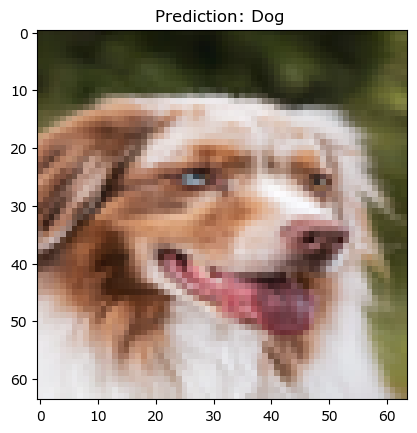

[[1]]


In [64]:
my_image = Image.open("DOGPIC.jpg")
my_image = my_image.convert("RGB")
my_image = my_image.resize((64, 64))
my_image = np.array(my_image)

my_image_flatten = my_image.reshape(64*64*3, -1)
my_image_norm = my_image_flatten / 255

result = predict(w, b, my_image_norm)

plt.imshow(my_image)
plt.title("Prediction: " + ("Dog " if result[0][0] == 1 else "Not Dog 🐱"))
plt.show()

print(result)

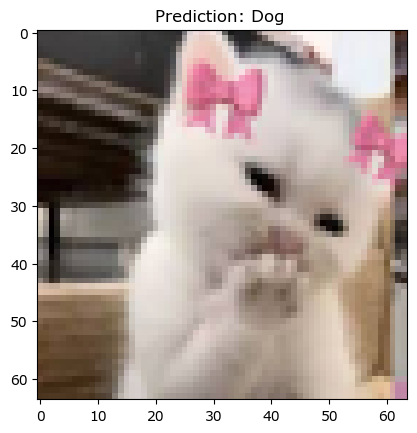

[[1]]


In [65]:
my_image = Image.open("CATPIC.jpg")
my_image = my_image.convert("RGB")
my_image = my_image.resize((64, 64))
my_image = np.array(my_image)

my_image_flatten = my_image.reshape(64*64*3, -1)
my_image_norm = my_image_flatten / 255

result = predict(w, b, my_image_norm)

plt.imshow(my_image)
plt.title("Prediction: " + ("Dog " if result[0][0] == 1 else "Not Dog 🐱"))
plt.show()

print(result)

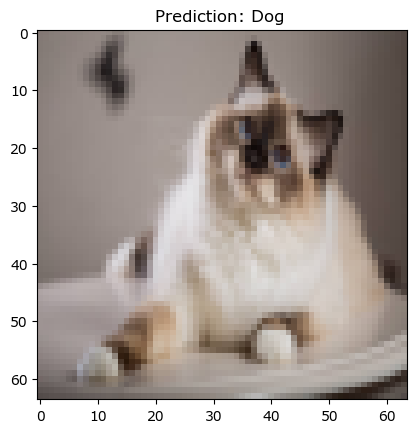

[[1]]


In [66]:
my_image = Image.open("CAT2.jpg")
my_image = my_image.convert("RGB")
my_image = my_image.resize((64, 64))
my_image = np.array(my_image)

my_image_flatten = my_image.reshape(64*64*3, -1)
my_image_norm = my_image_flatten / 255

result = predict(w, b, my_image_norm)

plt.imshow(my_image)
plt.title("Prediction: " + ("Dog " if result[0][0] == 1 else "Not Dog 🐱"))
plt.show()

print(result)

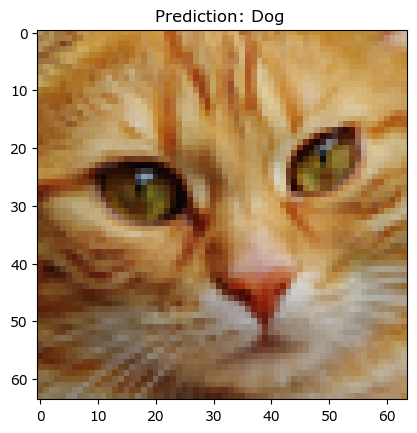

[[1]]


In [68]:
my_image = Image.open("CATT.jpg")
my_image = my_image.convert("RGB")
my_image = my_image.resize((64, 64))
my_image = np.array(my_image)

my_image_flatten = my_image.reshape(64*64*3, -1)
my_image_norm = my_image_flatten / 255

result = predict(w, b, my_image_norm)

plt.imshow(my_image)
plt.title("Prediction: " + ("Dog " if result[0][0] == 1 else "Not Dog 🐱"))
plt.show()

print(result)

In [69]:
print("Predictions on test set:")
print(Y_prediction_test)
print("Percentage predicted as Dog:", np.mean(Y_prediction_test)*100, "%")

print("\nPredictions on train set:")
print(Y_prediction_train)
print("Percentage predicted as Dog:", np.mean(Y_prediction_train)*100, "%")

Predictions on test set:
[[1 0 1 1 0 1 1 0 0 1 0 0 1 0 0 1 0 0 1 0 0 1 0 0 1 0 0 1 0 1 1 0 1 1 1 1
  1 1 1 1]]
Percentage predicted as Dog: 55.00000000000001 %

Predictions on train set:
[[1 1 1 1 1 1 1 0 1 1 0 0 1 0 0 1 0 0 1 0 0 1 0 1 1 0 1 1 0 1 1 0 1 1 0 1
  1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 1 1 1 0 1 1 0 1 1 0 1
  0 0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
Percentage predicted as Dog: 50.0 %
